In [1]:
import numpy as np, math
from scipy.optimize import brentq
try:
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    SPARSE_OK = True
except Exception:
    SPARSE_OK = False

# NOTE:
# self.t_v is the negative of the t_v used in the LaTeX notes:
#     t_v_code = - t_v_LaTeX.
# Therefore B_± = t_c exp(∓iK) + t_v_code,
# and the one-magnon hole-hopping matrix entries are +t_v_code.

class ExcitonMagnonSolver:
    """
    Three-sector exciton–magnon Green function on a 1-D FM chain.

    Basis (ΔS^z_tot = 0):
        |K;R⟩         singlet        (zero magnon)
        |K,T⁰;R⟩     S_z=0 triplet  (zero magnon)
        |K,T⁺;R,m⟩   T⁺ exciton + compensating magnon at relative site m

    R-block:  g_R = [ G_S(R), G_T0(R), G_T+(R,-M), …, G_T+(R,M) ]
    Full:     G   = [ g_{-Rmax}, …, g_{Rmax} ]
    """

    def __init__(self, t_c, t_v, Delta, J_FM, Je, Jv, s, gamma, U, Rmax, M):
        # ── model parameters ──
        self.t_c   = float(t_c)
        self.t_v   = float(t_v)
        self.Delta = float(Delta)
        self.J_FM  = float(J_FM)
        self.Je    = float(Je)
        self.Jv    = float(Jv)
        self.s     = float(s)
        self.gamma = float(gamma)
        self.U     = float(U)

        # ── truncation ──
        self.Rmax = int(Rmax)
        self.M    = int(M)
        #assert self.M >= self.Rmax, "Need M ≥ Rmax so m = R is always retained"

        # -- build index dictionary --
        self._build_basis()

        self.Ntot = len(self.idx2pair)
        self.alpha   = self.gamma * math.sqrt(self.s) / 2.0   # γ√s / 2
        self.Delta_J = (self.Jv - self.Je) * self.s / 2.0     # (Jv−Je)s / 2

    def _build_basis(self):
        self.idx2pair = []
        self.pair2idx = {}
        def push(key):
            self.pair2idx[key] = len(self.idx2pair)
            self.idx2pair.append(key)

        for R in range(-self.Rmax, self.Rmax + 1):
            push(('S', R))
            push(('T0', R))
            lo = min(-self.M, R - self.M)
            hi = max( self.M, R + self.M)
            for m in range(lo, hi + 1):
                if min(abs(m), abs(m - R)) <= self.M:
                    push(('Tp', R, m))



    # ════════════════════════════════════════════════════
    #  Reference dispersions
    # ════════════════════════════════════════════════════
    def eps_c(self, k): return 2.0*self.t_c*np.cos(k) + self.Delta
    def eps_v(self, k): return 2.0*self.t_v*np.cos(k)
    def eps_h(self, k): return -self.eps_v(k)

    # ════════════════════════════════════════════════════
    #  Index helpers
    # ════════════════════════════════════════════════════
    def _r(self, R):        return R + self.Rmax
    def idx_S(self, R):     return self.pair2idx[('S', R)]
    def idx_T0(self, R):    return self.pair2idx[('T0', R)]
    def idx_Tp(self, R, m): return self.pair2idx[('Tp', R, m)]
    def _R_ok(self, R):     return -self.Rmax <= R <= self.Rmax
    def _m_ok(self, R, m):  return min(abs(m), abs(m-R)) <= self.M

    # =====================================================
    # Adder
    # =================================================
    def add_if(self, add, i, key, val):
        j = self.pair2idx.get(key)
        if j is not None and val != 0:
            add(i, j, val)

    # ════════════════════════════════════════════════════
    #  Diagonal energies
    # ════════════════════════════════════════════════════
    def _E_Tp(self, R, m):
        """E^{T+}_{R,m} = (Je+Jv)s/2 − (Je/2)δ_{m0} − (Jv/2)δ_{mR}"""
        val = (self.Je + self.Jv) * self.s / 2.0
        if m == 0: val -= self.Je / 2.0
        if m == R: val -= self.Jv / 2.0
        return val

    def _diag_S(self, z, R):
        return z - self.Delta + (self.U if R == 0 else 0.0)

    def _diag_T0(self, z, R):
        return z - self.Delta + (self.U if R == 0 else 0.0)

    def _diag_Tp(self, z, R, m):
        return (z - self.Delta - 2.0*self.J_FM*self.s
                + self._E_Tp(R, m)
                + (self.U if R == 0 else 0.0))

    # ════════════════════════════════════════════════════
    #  Row-fill helpers
    # ════════════════════════════════════════════════════
    def _fill_S_row(self, add, R, z, Bp, Bm):
        """Singlet row at given R."""
        i = self.idx_S(R)
        add(i, i, self._diag_S(z, R))
        # hopping in R
        self.add_if(add, i, ('S', R-1), Bp)
        self.add_if(add, i, ('S', R+1), Bm)
        # S ↔ T⁰  (longitudinal s-d)
        add(i, self.idx_T0(R), self.Delta_J)
        # S → T⁺  (transverse s-d)
        add(i, self.idx_Tp(R,0), self.alpha * self.Je)
        self.add_if(add, i, ('Tp', R, R), -self.alpha * self.Jv)

    def _fill_T0_row(self, add, R, z, Bp, Bm):
        """T⁰ row at given R."""
        i = self.idx_T0(R)
        add(i, i, self._diag_T0(z, R))
        self.add_if(add, i, ('T0', R-1), Bp)
        self.add_if(add, i, ('T0', R+1), Bm)
        # T⁰ ↔ S  (longitudinal s-d)
        add(i, self.idx_S(R), self.Delta_J)
        # T⁰ → T⁺  (transverse s-d, note −αJv vs +αJv in singlet)
        add(i, self.idx_Tp(R, 0), self.alpha * self.Je)
        self.add_if(add, i, ('Tp', R, R), self.alpha * self.Jv)

    def _fill_Tp_row(self, add, R, m, z, exp_miK, exp_iK):
        """T⁺ row at given (R, m)."""
        i = self.idx_Tp(R, m)
        add(i, i, self._diag_Tp(z, R, m))

        # magnon hopping in m
        self.add_if(add, i, ('Tp', R, m-1), self.J_FM*self.s)
        self.add_if(add, i, ('Tp', R, m+1), self.J_FM*self.s)

        # electron hopping: (R,m) → (R±1, m±1)
        self.add_if(add, i, ('Tp', R-1, m-1), self.t_c * exp_miK)
        self.add_if(add, i, ('Tp', R+1, m+1), self.t_c * exp_iK)


        # hole hopping: (R,m) → (R±1, m)
        self.add_if(add, i, ('Tp', R-1, m), self.t_v)
        self.add_if(add, i, ('Tp', R+1, m), self.t_v)

        # T⁺ → S, T⁰  (magnon reabsorption)
        if m == 0:
            self.add_if(add, i, ('S', R),  self.alpha*self.Je)
            self.add_if(add, i, ('T0', R), self.alpha*self.Je)
        if m == R:
            self.add_if(add, i, ('S', R),  -self.alpha*self.Jv)
            self.add_if(add, i, ('T0', R),  self.alpha*self.Jv)

    # ════════════════════════════════════════════════════
    #  Assemble  M(z,K) G = e
    # ════════════════════════════════════════════════════
    def assemble(self, z, K):
        z = complex(z); K = float(K)

        exp_iK  = np.exp(1j*K)
        exp_miK = np.exp(-1j*K)
        Bp = self.t_c * exp_miK + self.t_v     # B₊ → couples to R−1
        Bm = self.t_c * exp_iK  + self.t_v     # B₋ → couples to R+1

        if SPARSE_OK:
            rows, cols, data = [], [], []
            def add(i, j, val):
                if val != 0:
                    rows.append(i); cols.append(j); data.append(val)
        else:
            Mat = np.zeros((self.Ntot, self.Ntot), dtype=np.complex128)
            def add(i, j, val):
                if val != 0:
                    Mat[i, j] += val

        e = np.zeros(self.Ntot, dtype=np.complex128)

        for tp in self.idx2pair:
            if tp[0] == 'S':
                self._fill_S_row(add, tp[1], z, Bp, Bm)
            elif tp[0] == 'T0':
                self._fill_T0_row(add, tp[1], z, Bp, Bm)
            elif tp[0] == 'Tp':
                self._fill_Tp_row(add, tp[1], tp[2], z, exp_miK, exp_iK)

        e[self.idx_S(0)] = 1.0

        if SPARSE_OK:
            Mat = sp.csr_matrix((data, (rows, cols)),
                                shape=(self.Ntot, self.Ntot),
                                dtype=np.complex128)
        return Mat, e

    # ════════════════════════════════════════════════════
    #  Accessors
    # ════════════════════════════════════════════════════
    def get_G_S(self, Gvec, R):     return Gvec[self.idx_S(R)]
    def get_G_T0(self, Gvec, R):    return Gvec[self.idx_T0(R)]
    def get_G_Tp(self, Gvec, R, m): return Gvec[self.idx_Tp(R, m)]

    # ════════════════════════════════════════════════════
    #  Solve and spectral
    # ════════════════════════════════════════════════════
    def solve(self, z, K, source='S', Rsrc=0, msrc=0):
        Mat, _ = self.assemble(z, K)
        e = np.zeros(self.Ntot, dtype=np.complex128)
        if source == 'S':
            e[self.idx_S(Rsrc)] = 1.0
        elif source == 'T0':
            e[self.idx_T0(Rsrc)] = 1.0
        elif source == 'Tp':
            e[self.idx_Tp(Rsrc, msrc)] = 1.0
        else:
            raise ValueError("source must be 'S', 'T0', or 'Tp'")
        if SPARSE_OK:
            return spla.spsolve(Mat, e)
        return np.linalg.solve(Mat, e)

    def spectral(self, K, omega, eta, R=0, sector='S', m=None,
                 *, source='S', Rsrc=0, msrc=0):
        z = omega + 1j*eta
        Gvec = self.solve(z, K, source=source, Rsrc=Rsrc, msrc=msrc)
        if sector == 'S':
            G = self.get_G_S(Gvec, R)
        elif sector == 'T0':
            G = self.get_G_T0(Gvec, R)
        elif sector == 'Tp':
            G = self.get_G_Tp(Gvec, R, m)
        else:
            raise ValueError("sector must be 'S', 'T0', or 'Tp'")
        return -np.imag(G) / np.pi

In [2]:
import os, time
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed

s = 1.5
Je = -0.5# Je negative, Jv = 0 checks the spin-polaron + hole continuum, both positive checks exciton + magnon
Jv = -0.5#-1
t_c = 1.0
J0 = 0.05
gamma = 1.0
t_v = 1.0
U = 0.1
Delta=0#11

params = dict(
    t_c=t_c,
    t_v=t_v,
    Delta=Delta,
    J_FM=J0,
    Je=Je,
    Jv=Jv,
    s=s,
    gamma=gamma,
    U=U,
    Rmax=40,
    M=10,
)


k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-7, 0, 200)
eta = 0.05

# Important: put these BEFORE importing numpy/scipy in a fresh kernel if possible.
# They prevent 28 processes × many BLAS threads = oversubscription.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


def effective_cpu_count():
    # Linux / cluster-safe: respects cpuset / Slurm affinity if enforced.
    try:
        return len(os.sched_getaffinity(0))
    except AttributeError:
        return int(os.environ.get("SLURM_CPUS_PER_TASK") or os.cpu_count() or 1)


n_workers = min(28, effective_cpu_count())

print("os.cpu_count() =", os.cpu_count())
print("effective_cpu_count() =", effective_cpu_count())
print("SLURM_CPUS_PER_TASK =", os.environ.get("SLURM_CPUS_PER_TASK"))
print("Using workers =", n_workers)


def compute_column(args):
    i, k, omega_values, eta, params = args

    pid = os.getpid()
    solver = ExcitonMagnonSolver(**params)

    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(
            k, w,
            eta=eta,
            R=0,
            sector="Tp",
            source="Tp",
            m = 0,#None
            Rsrc=0,
            msrc=0, #None
        )

    return i, col, pid


tasks = [(i, k, omega_values, eta, params) for i, k in enumerate(k_values)]

cols = [None] * len(k_values)
pid_counts = Counter()

t0 = time.time()

with ProcessPoolExecutor(max_workers=n_workers) as ex:
    futures = [ex.submit(compute_column, task) for task in tasks]

    for done, fut in enumerate(as_completed(futures), 1):
        i, col, pid = fut.result()
        cols[i] = col
        pid_counts[pid] += 1

        if done % 10 == 0 or done == len(futures):
            print(
                f"Finished {done}/{len(tasks)} k-columns | "
                f"worker PIDs seen: {len(pid_counts)}/{n_workers} | "
                f"elapsed: {time.time() - t0:.1f}s",
                flush=True,
            )

spectral_2d = np.stack(cols, axis=1)

print("Number of distinct worker processes used:", len(pid_counts))

spectral_cpu = spectral_2d.copy()

os.cpu_count() = 28
effective_cpu_count() = 28
SLURM_CPUS_PER_TASK = 28
Using workers = 28
Finished 10/200 k-columns | worker PIDs seen: 10/28 | elapsed: 139.3s
Finished 20/200 k-columns | worker PIDs seen: 20/28 | elapsed: 146.2s
Finished 30/200 k-columns | worker PIDs seen: 28/28 | elapsed: 267.0s
Finished 40/200 k-columns | worker PIDs seen: 28/28 | elapsed: 272.0s
Finished 50/200 k-columns | worker PIDs seen: 28/28 | elapsed: 279.7s
Finished 60/200 k-columns | worker PIDs seen: 28/28 | elapsed: 389.5s
Finished 70/200 k-columns | worker PIDs seen: 28/28 | elapsed: 402.9s
Finished 80/200 k-columns | worker PIDs seen: 28/28 | elapsed: 415.7s
Finished 90/200 k-columns | worker PIDs seen: 28/28 | elapsed: 525.8s
Finished 100/200 k-columns | worker PIDs seen: 28/28 | elapsed: 537.1s
Finished 110/200 k-columns | worker PIDs seen: 28/28 | elapsed: 554.4s
Finished 120/200 k-columns | worker PIDs seen: 28/28 | elapsed: 658.1s
Finished 130/200 k-columns | worker PIDs seen: 28/28 | elapsed: 67

In [3]:
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "text.usetex": False,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}\usepackage{amsmath}",  # lighter than newtx
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "mathtext.fontset": "stix",
    "axes.labelsize": 20, "axes.titlesize": 20,  # Slightly smaller for PRB style
    "xtick.labelsize": 20, "ytick.labelsize": 20,  # Smaller tick labels
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,  # Add minor ticks
    "legend.frameon": False,  # No frame for cleaner look
    "legend.fontsize": 20,  # Smaller legend font
    "lines.linewidth": 1.2,  # Slightly thicker lines
})

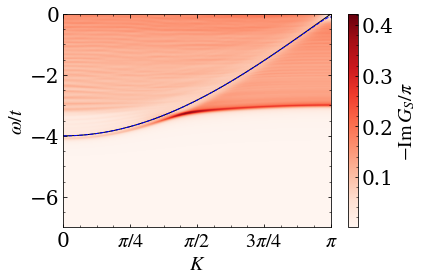

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(
    spectral_2d,
    origin='lower',
    extent=[k_values[0], k_values[-1], omega_values[0], omega_values[-1]],
    aspect='auto',
    cmap='Reds',
    interpolation='bilinear',
)

ax.set_xlabel(r'$K$')
ax.set_ylabel(r'$\omega / t$')
plt.plot(k_values, Delta-2*(t_c+t_v)*np.abs(np.cos(k_values/2)), color = "k", lw = 1)
plt.plot(k_values, Delta-np.sqrt(U**2 + 4 * (t_v**2 + t_c**2 + 2*t_c*t_v*np.cos(k_values))), ls = "--", color = "b", lw = 1)
# Nice k-axis ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 4))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: {0: '0', 1: r'$\pi/4$', 2: r'$\pi/2$', 3: r'$3\pi/4$', 4: r'$\pi$'}
    .get(round(x / (np.pi/4)), f'{x:.2f}')
))
ax.set_ylim(omega_values[0], omega_values[-1])
fig.colorbar(im, ax=ax, label=r'$-\mathrm{Im}\,G_S / \pi$')
fig.tight_layout()
plt.show()


In [5]:
from scipy.optimize import brentq


# =====================================================
# Model
# =====================================================
class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_e, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_e = float(J_e)
        self.s = float(s)
        self.gamma = float(gamma)


    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K):
        """
        Evaluate D(omega, K) on the real axis, ASSUMING omega is below the
        spin-polaron continuum so disc > 0 and D is purely real.
        Returns a real float. Use this for brentq.
        """
        omega = float(omega)
        K = float(K)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        # Below continuum: disc is real and positive
        disc_real = disc.real
        if disc_real < 0:
            disc_real = 0.0  # at the edge
        sqrt_disc = np.sqrt(disc_real)
        # rho candidates (A_minus is complex but for real omega below continuum,
        # A+A- is real, so alpha^2 - 4A+A- is real, and rho is real)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2
        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        result = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma
        return result.real

    def sp_continuum_edge(self, K):
        """
        Lower edge of the spin-polaron continuum at momentum K.
        This is where disc = alpha^2 - 4 A+ A- = 0.
        The continuum is the electron-magnon scattering states:
           E(K,q) = -2t cos(K-q) + 2 J0 s (1 - cos q) + Je s / 2
        Minimized over magnon momentum q.
        """
        K = float(K)
        q_grid = np.linspace(-np.pi, np.pi, 5000)
        E_vals = (-2.0 * self.t * np.cos(K - q_grid)
                  + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q_grid))
                  + 0.5 * self.J_e * self.s)
        return np.min(E_vals)

    def G_minus(self, z, K):
        return 1.0 / self.denominator(z, K)

    def spectral_weight(self, K, omega, eta=2e-2):
        z = omega + 1j * eta
        return -np.imag(self.G_minus(z, K)) / np.pi


# =====================================================
# Band extraction (vectorized scan + brentq)
# =====================================================
def _lowest_root(D, p, w_lo, w_hi, n_scan, xtol):
    w = np.linspace(w_lo, w_hi, n_scan)
    Dw = D(w, p)                                     # single vectorized call
    finite = np.isfinite(Dw)
    if not np.all(finite):                           # guard against NaN brackets
        Dw = np.where(finite, Dw, np.nan)
    sc = np.flatnonzero(np.diff(np.signbit(Dw)) & finite[:-1] & finite[1:])
    if sc.size == 0:
        return None
    roots = []
    for i in sc:
        try:
            roots.append(brentq(lambda x: D(x, p), w[i], w[i + 1], xtol=xtol))
        except Exception:
            pass
    return min(roots) if roots else None


def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8,
                                     n_scan=400, xtol=1e-12):
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])
    D = pol.denominator_real_below_continuum

    for j, p in enumerate(p_grid):
        w_hi = E_cont[j] - padding
        if w_hi <= wmin:
            continue
        root = _lowest_root(D, p, wmin, w_hi, n_scan, xtol)
        if root is None:                             # geometric edge refinement
            for depth in range(8):
                w_lo = max(wmin, w_hi - 0.5 * 0.1**depth)
                if w_hi - w_lo < 1e-15:
                    break
                root = _lowest_root(D, p, w_lo, w_hi, n_scan, xtol)
                if root is not None:
                    break
        if root is not None:
            E_sp[j] = root
    return E_sp, E_cont


# =====================================================
# Spin-polaron + hole continuum
# =====================================================
def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


def spin_polaron_hole_continuum(K_ex_grid, p_grid, E_sp, t_v, *, Jv=0.0, s=0.5):
    """
    E_cont(K) = min_p [ E_sp(p) + E_h(K - p) + Jv*s/2 ]
    """
    K_ex_grid = np.asarray(K_ex_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    valid = np.isfinite(E_sp)
    if not np.any(valid):
        raise RuntimeError("No valid spin-polaron poles in E_sp.")

    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    k_h = wrap_to_bz(K_ex_grid[:, None] - p_valid[None, :])
    E_h = -2.0 * t_v * np.cos(k_h) + 0.5 * Jv * s
    E_mat = E_valid[None, :] + E_h

    idx = np.argmin(E_mat, axis=1)
    rows = np.arange(K_ex_grid.size)
    E_cont = E_mat[rows, idx]
    p_star = p_valid[idx]
    k_h_star = k_h[rows, idx]
    return E_cont, p_star, k_h_star


Computing spectral weight on 2D grid...
Progress: 0/200
Progress: 20/200
Progress: 40/200
Progress: 60/200
Progress: 80/200
Progress: 100/200
Progress: 120/200
Progress: 140/200
Progress: 160/200
Progress: 180/200
Plot saved to outputs/spectral_function_2d.png


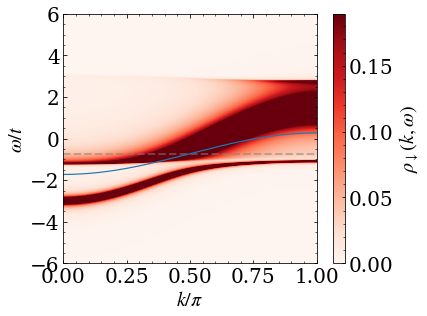

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# ----- Parameters (consistent with SM Fig. 2) -----
s = s
J1 = 1#-Je#5         # choose |J| = 1 as energy unit
W = 10.0
t = 1      # W = 4t
#omega_m = 0.01
#J0 = 0.05#omega_m / (4.0 * s)   # correct mapping
gamma = 1.0

pol = RealSpaceMagneticPolaron(t, J0, J1, s, gamma)

# Create k and omega grids

omega_values_sp = np.linspace(-6*t, 6*t, 400)
eta = 0.02

# Compute spectral weight on 2D grid
print("Computing spectral weight on 2D grid...")
spectral_2d_sp = np.zeros((len(omega_values_sp), len(k_values)))

for i, k in enumerate(k_values):
    if i % 20 == 0:
        print(f"Progress: {i}/{len(k_values)}")
    for j, omega in enumerate(omega_values_sp):
        spectral_2d_sp[j, i] = pol.spectral_weight(k, omega, eta=eta)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot as 2D image
im = ax.imshow(spectral_2d_sp, 
               extent=[0, 1, omega_values_sp[0]/t, omega_values_sp[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

# Add dashed line at omega=0 (or wherever appropriate)
ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
#ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.plot(k_values/np.pi, -3/4*J1 + J0/2 -np.cos(k_values))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
plt.show()


branch = below
valid = 500 / 500
min separation = 0.026290933961641727
max separation = 0.8516475432175081


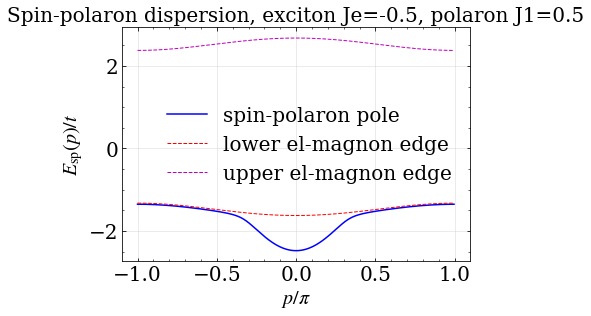

In [7]:
import numpy as np
from scipy.optimize import brentq


def em_edges_fast(pol, K):
    Aabs = abs(pol.t * np.exp(1j*K) + pol.J_0 * pol.s)
    center = 2.0 * pol.J_0 * pol.s + 0.5 * pol.J_e * pol.s
    return center - 2.0*Aabs, center + 2.0*Aabs


def self_energy_pole_energy(pol, K, branch):
    """
    Location where beta + 2 A_- rho = 0.
    The physical spin-polaron pole lies on the far side of this singularity.
    """
    J = pol.J_e
    Aabs = abs(pol.t * np.exp(1j*K) + pol.J_0 * pol.s)
    center = 2.0 * pol.J_0 * pol.s + 0.5 * J * pol.s

    alpha_abs = np.sqrt(4.0*Aabs*Aabs + 0.25*J*J)

    if branch == "below":
        return center - alpha_abs
    elif branch == "above":
        return center + alpha_abs
    else:
        raise ValueError("branch must be 'below' or 'above'")


def D_outside_fast(pol, omega, K, branch):
    J = pol.J_e

    if branch == "below":
        sigma = -1.0
    elif branch == "above":
        sigma = +1.0
    else:
        raise ValueError("branch must be 'below' or 'above'")

    Aabs = abs(pol.t * np.exp(1j*K) + pol.J_0 * pol.s)
    center = 2.0 * pol.J_0 * pol.s + 0.5 * J * pol.s

    alpha = omega - center
    rad = alpha*alpha - 4.0*Aabs*Aabs

    if rad <= 0.0:
        return np.nan

    root = np.sqrt(rad)
    denom_self = 0.5*J + sigma*root

    g2 = (pol.gamma * J)**2 * pol.s / 2.0

    return (
        omega
        + 2.0 * pol.t * np.cos(K)
        + 0.5 * J * pol.s
        - g2 / denom_self
    )

def extract_spin_polaron_band_fast(pol, p_grid,
                                   branch="auto",
                                   eps=1e-9,
                                   xtol=1e-11,
                                   rtol=1e-11,
                                   max_expand=30):
    """
    Fast extraction of the isolated spin-polaron pole.

    For polaron convention:
        J_e > 0: bound pole below continuum.
        J_e < 0: antibound pole above continuum.
    """
    p_grid = np.asarray(p_grid, dtype=float)

    if branch == "auto":
        if pol.J_e > 0:
            branch = "below"
        elif pol.J_e < 0:
            branch = "above"
        else:
            raise ValueError("pol.J_e = 0 has no spin-polaron pole.")

    if branch not in ("below", "above"):
        raise ValueError("branch must be 'auto', 'below', or 'above'.")

    E_sp = np.full_like(p_grid, np.nan, dtype=float)
    E_low = np.empty_like(p_grid, dtype=float)
    E_high = np.empty_like(p_grid, dtype=float)
    E_sing = np.empty_like(p_grid, dtype=float)

    scale = max(1.0, abs(pol.t), abs(pol.J_0*pol.s), abs(pol.J_e))

    for i, K in enumerate(p_grid):
        E_low[i], E_high[i] = em_edges_fast(pol, K)
        w_pole = self_energy_pole_energy(pol, K, branch)
        E_sing[i] = w_pole

        # The physical isolated pole is on the far side of the self-energy singularity.
        if branch == "below":
            b = w_pole - eps*scale
            fb = D_outside_fast(pol, b, K, branch)

            span = scale
            for _ in range(max_expand):
                a = w_pole - span
                fa = D_outside_fast(pol, a, K, branch)

                if np.isfinite(fa) and np.isfinite(fb) and fa*fb < 0.0:
                    E_sp[i] = brentq(
                        lambda w: D_outside_fast(pol, w, K, branch),
                        a, b,
                        xtol=xtol,
                        rtol=rtol,
                        maxiter=80,
                    )
                    break

                span *= 2.0

        else:
            a = w_pole + eps*scale
            fa = D_outside_fast(pol, a, K, branch)

            span = scale
            for _ in range(max_expand):
                b = w_pole + span
                fb = D_outside_fast(pol, b, K, branch)

                if np.isfinite(fa) and np.isfinite(fb) and fa*fb < 0.0:
                    E_sp[i] = brentq(
                        lambda w: D_outside_fast(pol, w, K, branch),
                        a, b,
                        xtol=xtol,
                        rtol=rtol,
                        maxiter=80,
                    )
                    break

                span *= 2.0

    return E_sp, E_low, E_high, E_sing, branch

J1_pol = -Je

pol = RealSpaceMagneticPolaron(
    t=t_c,
    J_0=J0,
    J_e=J1_pol,
    s=s,
    gamma=gamma,
)

p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)

E_sp, E_low, E_high, E_sing, branch = extract_spin_polaron_band_fast(
    pol,
    p_grid,
    branch="auto",
)

print("branch =", branch)
print("valid =", np.sum(np.isfinite(E_sp)), "/", len(E_sp))

if branch == "below":
    sep = E_low - E_sp
else:
    sep = E_sp - E_high

print("min separation =", np.nanmin(sep))
print("max separation =", np.nanmax(sep))

fig, ax = plt.subplots(figsize=(6, 4.5))

ax.plot(p_grid / np.pi, E_sp, 'b-', lw=1.5, label='spin-polaron pole')
ax.plot(p_grid / np.pi, E_low, 'r--', lw=1, label='lower el-magnon edge')
ax.plot(p_grid / np.pi, E_high, 'm--', lw=1, label='upper el-magnon edge')

ax.set_xlabel(r'$p/\pi$')
ax.set_ylabel(r'$E_{\rm sp}(p)/t$')
ax.set_title(f'Spin-polaron dispersion, exciton Je={Je}, polaron J1={J1_pol}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
#    K_ex_grid=K_ex,
#    p_grid=p_grid,
#    E_sp=E_sp,
#    t_v=t_v,
#    Jv=-Jv,
#    s=s,
#)

In [8]:
def spin_polaron_hole_continuum(K_grid, p_grid, E_sp, t_v, Jv, s, *, return_all=True):
    """
    Spin-polaron + free-hole continuum.

    Total momentum:
        K = p_sp + k_h

    Hole momentum:
        k_h = K - p_sp

    Hole dispersion:
        E_h(k_h) = -2 t_v cos(k_h)

    Continuum:
        E(K, p) = E_sp(p) - 2 t_v cos(K - p)

    Inputs
    ------
    K_grid : array
        Total exciton momentum grid.
    p_grid : array
        Spin-polaron momentum grid.
    E_sp : array
        Extracted spin-polaron dispersion on p_grid.
    t_v : float
        Hole hopping in the convention E_h(k) = -2 t_v cos(k).

    Returns
    -------
    E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high, E_all
    """
    K_grid = np.asarray(K_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    valid = np.isfinite(E_sp)
    if not np.any(valid):
        raise RuntimeError("E_sp contains no valid spin-polaron poles.")

    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    K2 = K_grid[:, None]
    P  = p_valid[None, :]

    k_h = K2 - P
    E_h = -2.0 * t_v * np.cos(k_h)

    E_all = E_valid[None, :] + E_h - Jv * s /2

    idx_low = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    rows = np.arange(K_grid.size)

    E_low = E_all[rows, idx_low]
    E_high = E_all[rows, idx_high]

    p_star_low = p_valid[idx_low]
    p_star_high = p_valid[idx_high]

    k_h_low = k_h[rows, idx_low]
    k_h_high = k_h[rows, idx_high]

    if return_all:
        return E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high, p_valid, E_all

    return E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_to_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def exciton_bound_energy(k, t_c, t_v, U, Je=0.0, s=0.5):
    """
    Exact exciton bound-state dispersion in the reduced momentum variable k,
    where the formula depends on cos(k).

    k can be scalar or array.
    """
    A = t_c**2 + t_v**2 + 2.0*t_c*t_v*np.cos(k)
    E = -np.sqrt(U**2 + 4.0*A)   # lower / bound branch
    return E



def magnon_dispersion(q, J0, s, Je, Jv):
    """
    Exact 1D FM magnon dispersion in the same energy convention as your solver.
    """
    return 2.0*J0*s*(1.0 - np.cos(q)) + Je*s/2 + Jv*s/2

def exciton_magnon_continuum(K_grid, t_c, t_v, U, J0, s, Je=0.0, Jv=0.0,
                             nq=400):
    """
    Exciton + magnon continuum in the exciton-magnon solver convention.

    K_grid: solver momentum variable K in [0, pi]
    q: physical magnon momentum in [-pi, pi)
    Exciton reduced momentum is k_X = K - q, so cos( k_X) = cos(K - q).

    Returns:
      E_low(K), E_high(K), q_star_low(K), q_star_high(K), E_all(K,q)
    """
    K_grid = np.asarray(K_grid, dtype=float)
    q_grid = np.linspace(-np.pi, np.pi, nq, endpoint=False)

    # Broadcast over K and q
    K2 = K_grid[:, None]
    Q  = q_grid[None, :]

    # Exciton reduced momentum in your exact formula
    kX = K2 - Q

    EX = exciton_bound_energy(
        kX, t_c=t_c, t_v=t_v, U=U, Je=Je, s=s
    )
    WM = magnon_dispersion(Q, J0=J0, s=s, Je=Je, Jv=Jv)

    E_all = EX + WM

    idx_low  = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    E_low  = E_all[np.arange(len(K_grid)), idx_low]
    E_high = E_all[np.arange(len(K_grid)), idx_high]

    q_star_low  = q_grid[idx_low]
    q_star_high = q_grid[idx_high]

    return E_low, E_high, q_star_low, q_star_high, q_grid, E_all

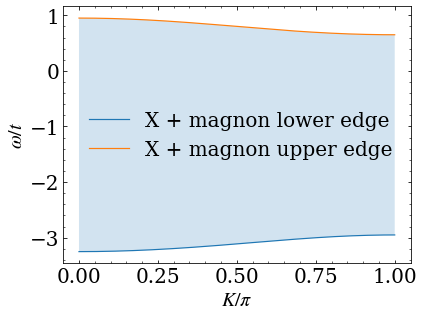

In [10]:
# Parameters


K_grid = k_values

E_low, E_high, q_low, q_high, q_grid, E_all = exciton_magnon_continuum(
    K_grid,
    t_c=t_c,
    t_v=t_v,
    U=-U,
    J0=J0,
    s=s,
    Je=-Je,
    Jv=-Jv,
    nq=400,
)

# Plot edges
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(k_values/np.pi, E_low,  label='X + magnon lower edge')
ax.plot(k_values/np.pi, E_high, label='X + magnon upper edge')
ax.fill_between(K_grid/np.pi, E_low, E_high, alpha=0.2)
ax.set_xlabel(r'$K/\pi$')
ax.set_ylabel(r'$\omega/t$')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
J1_pol = -Je

pol = RealSpaceMagneticPolaron(
    t=t_c,
    J_0=J0,
    J_e=J1_pol,
    s=s,
    gamma=gamma,
)

p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)

E_sp, E_low_sp, E_high_sp, E_sing, branch = extract_spin_polaron_band_fast(
    pol,
    p_grid,
    branch="auto",
)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
#binding = E_sp_cont - E_sp
#print(f"  Min binding energy: {np.nanmin(binding):.6f}")
#print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values   # or np.linspace(0, np.pi, ...)
E_low_sp_h, E_high_sp_h, p_low, p_high, kh_low, kh_high, p_valid, E_all_sp_h = (
    spin_polaron_hole_continuum(
        K_grid=K_ex,
        p_grid=p_grid,
        E_sp=E_sp,
        t_v=t_v,
        Jv = Jv,
        s = s,
        return_all=True,
    )
)




  Found poles at 500/500 k-points


Plot saved to outputs/spectral_function_2d.png


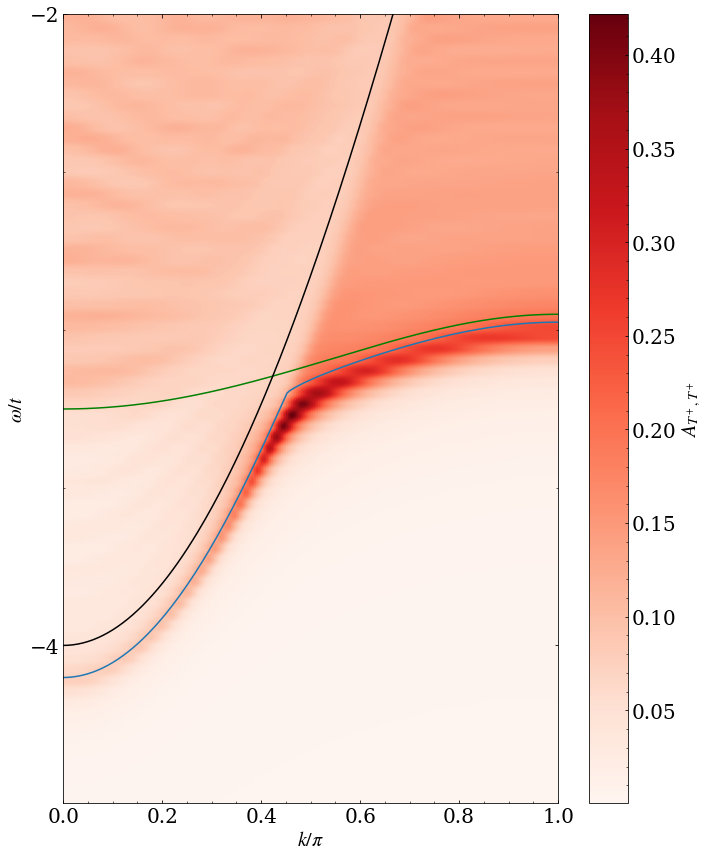

In [14]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 12))

# Plot as 2D image
im = ax.imshow(spectral_2d,
               extent=[0, 1, omega_values[0], omega_values[-1]],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
                )

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$A_{T^+,T^+}$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )

ax.plot(k_values/np.pi, E_low_sp_h, label="spin-polaron+hole", lw=1.5)
#ax.plot(k_values/np.pi, H_cont, label="hole-spin-polaron+hole", color = "cyan", lw=1)
ax.plot(k_values/np.pi, E_low, color='g', lw=1.5)
#plt.plot(k_values/np.pi, min_values_abs)
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, -4*np.abs(t_c*np.cos(k_values)))
plt.plot(k_values/np.pi, -2*(t_c+t_v)*np.abs(np.cos(k_values/2)), color = "k", lw=1.5)
plt.ylim(-4.5,-2)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes,
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')
#ax.set_ylim(omega_values[0], omega_values[-1])
#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

In [107]:
import numpy as np


def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


def sp_hole_dos(K, p_grid, E_sp, t_v, omega_grid, *,
                Jv=0.0, s=0.5, eta=1e-3, n_fine=200000):
    """
    Local density of SP + hole product states at fixed exciton momentum K:

        rho(E) = sum_p delta( E - E_sp(p) - E_h(K - p) )

    E_h(k) = -2 t_v cos(k) + 0.5 Jv s.

    Returns three estimators on omega_grid:
      rho_lor  : Lorentzian-smeared with width eta  (compare directly to image 1)
      rho_hist : raw histogram (bin = omega_grid spacing)
      rho_vh   : sharp van Hove sum  sum_{p*} 1/|dE/dp|
    Also returns E_branch(p_fine) = E_sp(p) + E_h(K-p) for inspection.
    """
    p_grid = np.asarray(p_grid, float)
    E_sp = np.asarray(E_sp, float)
    omega_grid = np.asarray(omega_grid, float)

    # --- interpolate the (possibly coarse, NaN-holed) SP band onto a fine p-grid
    valid = np.isfinite(E_sp)
    if valid.sum() < 2:
        raise RuntimeError("Need >=2 valid SP poles to interpolate.")
    p_v, E_v = p_grid[valid], E_sp[valid]
    order = np.argsort(p_v)
    p_v, E_v = p_v[order], E_v[order]

    p_fine = np.linspace(p_v.min(), p_v.max(), n_fine)
    E_sp_f = np.interp(p_fine, p_v, E_v)

    k_h = wrap_to_bz(K - p_fine)
    E_h_f = -2.0 * t_v * np.cos(k_h) + 0.5 * Jv * s
    E_branch = E_sp_f + E_h_f                      # E(p) on the fine grid

    # measure of states per unit p: uniform fine grid -> weight dp each
    dp = p_fine[1] - p_fine[0]

    # --- (1) Lorentzian-smeared DOS  (matches a +i eta Green's function)
    # rho_lor(E) = (1/pi) sum_p [ eta / ((E-E(p))^2 + eta^2) ] * (dp / (2 pi))
    rho_lor = np.zeros_like(omega_grid)
    chunk = 4000                                   # rows of E_branch per pass
    for a in range(0, E_branch.size, chunk):
        eb = E_branch[a:a + chunk]
        diff = omega_grid[:, None] - eb[None, :]
        rho_lor += (eta / (diff**2 + eta**2)).sum(axis=1)
    rho_lor *= (1.0 / np.pi) * dp / (2.0 * np.pi)

    # --- (2) raw histogram (counts per bin -> per unit energy), normalized to states/(2pi)
    bins = np.concatenate([
        omega_grid - 0.5 * np.gradient(omega_grid),
        [omega_grid[-1] + 0.5 * (omega_grid[-1] - omega_grid[-2])],
    ])
    counts, _ = np.histogram(E_branch, bins=bins)
    bin_w = np.diff(bins)
    rho_hist = counts * (dp / (2.0 * np.pi)) / bin_w

    # --- (3) sharp van Hove sum  rho(E) = sum_{p*: E(p*)=E} 1/|dE/dp| / (2 pi)
    dE = np.gradient(E_branch, p_fine)            # group-velocity diff v_sp - v_h
    rho_vh = np.zeros_like(omega_grid)
    for i, E0 in enumerate(omega_grid):
        s_arr = np.signbit(E_branch - E0)
        cross = np.flatnonzero(np.diff(s_arr))    # bracketed roots E(p*)=E0
        acc = 0.0
        for c in cross:
            slope = abs(dE[c])
            if slope > 1e-14:
                acc += 1.0 / slope
        rho_vh[i] = acc / (2.0 * np.pi)

    return {
        "rho_lor": rho_lor,
        "rho_hist": rho_hist,
        "rho_vh": rho_vh,
        "p_fine": p_fine,
        "E_branch": E_branch,
        "E_min": float(E_branch.min()),
        "E_max": float(E_branch.max()),
    }

In [98]:
s = 1.5
Je = -0.5# 0.1
Jv = -0.5# 0.1
t_c = 1.0
J0 = 0.2
gamma = 1.0
t_v = 1.0
U = 0.1 # 0.1 dissociate, above 0.4 there are no more dissociation
eta = 0.01
# as long as J's are positive and U is small, then we have dissociation
# When J's are negative, then Tp will always have an exciton below the continuum

params = dict(
    t_c=t_c,
    t_v=t_v,
    Delta=0,
    J_FM=J0,
    Je=Je,
    Jv=Jv,
    s=s,
    gamma=gamma,
    U=U,
    Rmax=800,
    M=8,
)

In [99]:
J1_pol = -Je

pol = RealSpaceMagneticPolaron(
    t=t_c,
    J_0=J0,
    J_e=J1_pol,
    s=s,
    gamma=gamma,
)

p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)

E_sp, E_low_sp, E_high_sp, E_sing, branch = extract_spin_polaron_band_fast(
    pol,
    p_grid,
    branch="auto",
)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
#binding = E_sp_cont - E_sp
#print(f"  Min binding energy: {np.nanmin(binding):.6f}")
#print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values   # or np.linspace(0, np.pi, ...)
E_low_sp_h, E_high_sp_h, p_low, p_high, kh_low, kh_high, p_valid, E_all_sp_h = (
    spin_polaron_hole_continuum(
        K_grid=K_ex,
        p_grid=p_grid,
        E_sp=E_sp,
        t_v=t_v,
        Jv = Jv,
        s = s,
        return_all=True,
    )
)

  Found poles at 500/500 k-points


In [100]:
pk = -4.1#E_cont[0]
k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(pk-5*eta, pk+5*eta, 50)


solver = ExcitonMagnonSolver(**params)

In [101]:
col = np.empty(len(omega_values), dtype=float)
for j, w in enumerate(omega_values):
    col[j] = solver.spectral(
        0, w,
        eta=eta,
        R=0,
        sector="Tp",
        source="Tp",
        m = 0,#None
        Rsrc=0,
        msrc=0, #None
    )

In [102]:
pol = RealSpaceMagneticPolaron(t_c, J0, -Je, s)
p_grid = np.linspace(-np.pi, np.pi, 2001)
#E_sp, _ = extract_lowest_spin_polaron_band(pol, p_grid)
#print(E_sp)
#out = sp_hole_dos(0.0, p_grid, E_sp, t_v, omega_values, Jv=-Jv, s=s, eta=1e-3)

(array([-4.5, -4.4, -4.3, -4.2, -4.1, -4. ]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

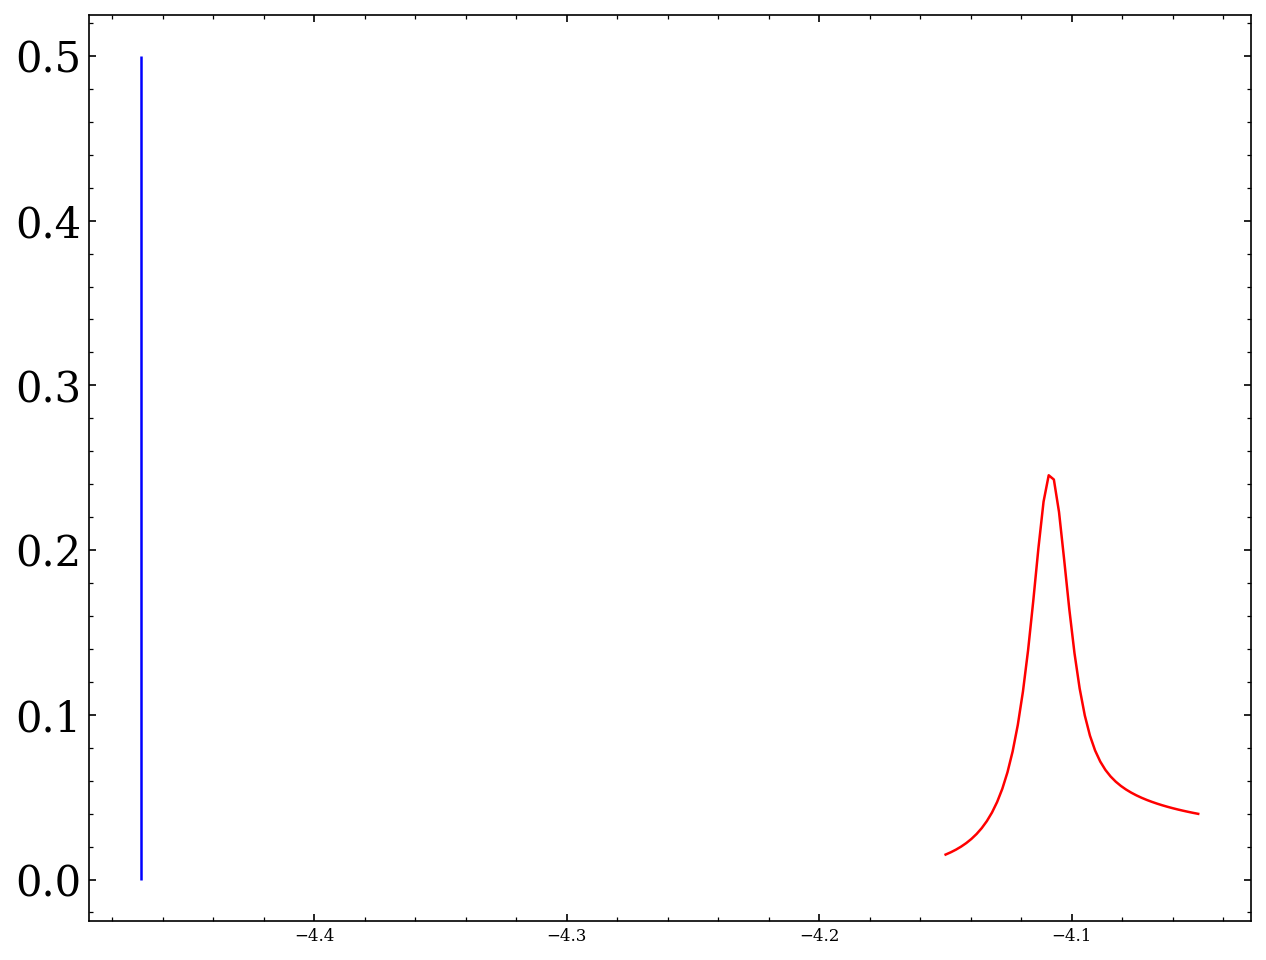

In [103]:
plt.subplots(figsize=(10, 8))
plt.plot(omega_values, col, color = "r")
plt.vlines(E_low_sp_h[0],0,0.5, color = "b")
#plt.plot(omega_values,out["rho_hist"])
#plt.ylim(0,7)
plt.xticks(fontsize=8)

In [104]:
def level_spacing_on_shell(K, p_grid, E_sp, t_v, E_peak, Rmax, eta,
                           *, Jv=0.0, s=0.5, n_fine=200000):
    """
    Box level spacing of the SP+hole continuum at the on-shell point(s).

      v_rel(p) = d/dp [ E_sp(p) + E_h(K-p) ]          (relative group velocity)
      dE       = |v_rel(p*)| * 2*pi / (2 Rmax + 1)     (level spacing in the box)

    p* solves E_sp(p*) + E_h(K-p*) = E_peak.
    Compares dE to eta: eta > dE  -> levels bridged, a real width would show.
                        eta < dE  -> levels resolved; width~eta is the
                                     discrete-pole signature (no genuine decay yet).
    Returns a list of dicts, one per on-shell root.
    """
    p_grid = np.asarray(p_grid, float)
    E_sp   = np.asarray(E_sp, float)

    valid = np.isfinite(E_sp)
    if valid.sum() < 2:
        raise RuntimeError("Need >=2 valid SP poles.")
    p_v, E_v = p_grid[valid], E_sp[valid]
    order = np.argsort(p_v); p_v, E_v = p_v[order], E_v[order]

    p_fine = np.linspace(p_v.min(), p_v.max(), n_fine)
    E_sp_f = np.interp(p_fine, p_v, E_v)
    k_h    = (K - p_fine + np.pi) % (2*np.pi) - np.pi
    E_h_f  = -2.0*t_v*np.cos(k_h) + 0.5*Jv*s
    E_branch = E_sp_f + E_h_f
    v_branch = np.gradient(E_branch, p_fine)             # v_rel along the branch

    # genuine vs interpolated: within one coarse spacing of a real valid p
    dp_coarse = np.min(np.diff(p_v))
    nearest   = np.min(np.abs(p_fine[:, None] - p_v[None, :]), axis=1)
    genuine   = nearest <= dp_coarse

    L  = 2*Rmax + 1
    dk = 2.0*np.pi / L

    sgn  = np.signbit(E_branch - E_peak)
    cross = np.flatnonzero(np.diff(sgn))

    results = []
    for c in cross:
        v   = abs(v_branch[c])
        dE  = v * dk
        results.append({
            "p_star":   float(p_fine[c]),
            "v_rel":    float(v),
            "delta_E":  float(dE),
            "eta":      float(eta),
            "eta_gt_dE": bool(eta > dE),
            "genuine":  bool(genuine[c]),
            "verdict": (
                "p* in interpolated gap -> channel may be fictitious"
                if not genuine[c] else
                ("eta > dE : levels bridged, real width WOULD appear -> "
                 "no-width is NOT DOS starvation"
                 if eta > dE else
                 "eta < dE : levels resolved -> width~eta is expected discrete-pole "
                 "signature, consistent with DOS starvation")
            ),
        })
    return results



# ---- replace these with your real values ----
p_grid = np.linspace(-np.pi, np.pi, 2001)
K      = 0.0
E_peak = -4.5                         # <-- your exciton peak energy
Rmax = 100

#for r in level_spacing_on_shell(K, p_grid, E_sp, t_v, E_peak, Rmax, eta, Jv=-Jv, s=s):
#    print(f"p*={r['p_star']:+.4f}  v_rel={r['v_rel']:.4f}  "
#          f"dE={r['delta_E']:.5f}  eta={r['eta']:.5f}  genuine={r['genuine']}")
#    print("   ->", r["verdict"])


In [105]:
from scipy.signal import find_peaks, peak_widths

In [106]:
peaks, _ = find_peaks(col)
results_half = peak_widths(col, peaks, rel_height=0.5)[0]*(omega_values[1]-omega_values[0])

print(results_half)
print(peaks*(omega_values[1]-omega_values[0]) + omega_values[0])

[0.01773304]
[-4.10918367]


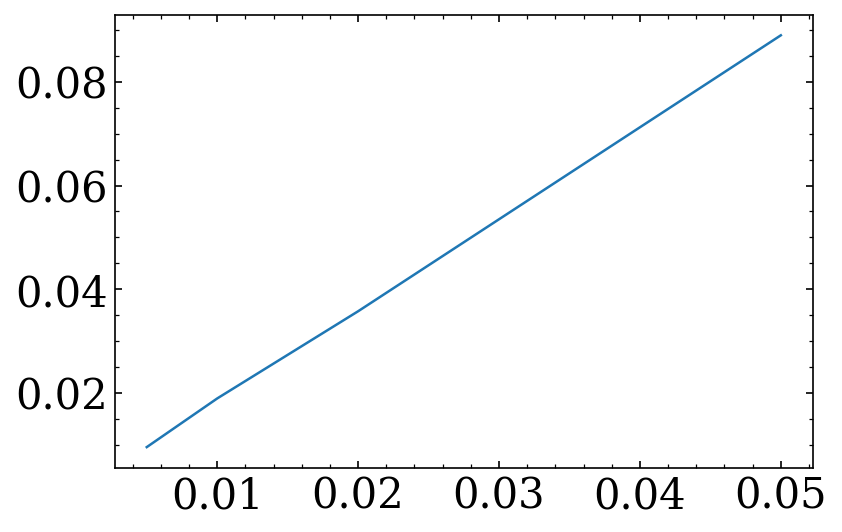

In [119]:
import matplotlib.pyplot as plt
data = np.array([
    [0.05,   0.09257689],
    [0.02,   0.03574899],
    [0.01,  0.01773304],
    #[0.005,  0.00953265],
    #[0.002,  0.00384549],
    #[0.001, 0.00191317],
    #[0.00002, 3.22486777e-05],
    #[0.00001, 1.63494449e-05],
])

plt.plot(data[:,0], data[:,1])
#plt.xticks(fontsize=8)

In [44]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# ---------------------------------------------------------------------------
# Core: one solve per (omega, eta).  Contracts with a source vector in the
# A-block BEFORE solving, so cost is 1 sparse solve instead of nA solves.
# ---------------------------------------------------------------------------
def _sigma_contracted(solver, omega, K, eta, src_A, A_idx, B_idx):
    """
    Sigma_c(z) = src^dagger M_AB (M_BB)^{-1} M_BA src,   z = omega + i eta.
    src_A : complex vector over the A-block (length len(A_idx)).
    Returns complex Sigma_c.
    """
    z = omega + 1j * eta
    Mat, _ = solver.assemble(z, K)
    Mat = sp.csr_matrix(Mat)

    M_AB = Mat[A_idx][:, B_idx]
    M_BA = sp.csc_matrix(Mat[B_idx][:, A_idx])
    M_BB = sp.csc_matrix(Mat[B_idx][:, B_idx])

    vB = M_BA @ src_A                 # (nB,)  one mat-vec
    x = spla.spsolve(M_BB, vB)        # ONE solve
    return complex(np.vdot(src_A, M_AB @ x))


def _make_src(solver, A_idx, weights):
    """
    Build an A-block source vector.
    weights: either
       - 'S0'              : delta on S(R=0)        (original behavior)
       - dict {R: amp}     : exciton wavefunction over S-sites
       - 1D array len 2Rmax+1 indexed R=-Rmax..Rmax
    """
    nA = len(A_idx)
    posA = {gi: a for a, gi in enumerate(A_idx)}
    src = np.zeros(nA, dtype=np.complex128)
    Rmax = solver.Rmax
    if isinstance(weights, str) and weights == 'S0':
        src[posA[solver.idx_S(0)]] = 1.0
    elif isinstance(weights, dict):
        for R, amp in weights.items():
            if amp != 0:
                src[posA[solver.idx_S(R)]] = amp
    else:
        arr = np.asarray(weights)
        for R in range(-Rmax, Rmax + 1):
            amp = arr[R + Rmax]
            if amp != 0:
                src[posA[solver.idx_S(R)]] = amp
    return src


def _partition(solver):
    pairs = solver.idx2pair
    A_idx = np.array([i for i, p in enumerate(pairs) if p[0] in ('S', 'T0')], dtype=int)
    B_idx = np.array([i for i, p in enumerate(pairs) if p[0] == 'Tp'], dtype=int)
    return A_idx, B_idx


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------
def singlet_self_energy(solver, omega, K, eta, *, weights='S0'):
    """
    Contracted singlet self-energy at one energy.
    weights: 'S0' (R=0 element, will be ~0 at Je=Jv due to contact cancellation)
             or exciton wavefunction (dict/array) for the TRUE decay rate.
    """
    A_idx, B_idx = _partition(solver)
    src = _make_src(solver, A_idx, weights)
    Sig = _sigma_contracted(solver, omega, K, eta, src, A_idx, B_idx)
    return {"omega": float(omega), "eta": float(eta),
            "Sigma": Sig, "Re_Sigma": float(Sig.real),
            "Im_Sigma": float(Sig.imag), "Gamma": float(-2.0 * Sig.imag)}


def self_energy_scan(solver, omega_grid, K, eta, *, weights='S0'):
    """Scan over omega at fixed eta. One solve per omega."""
    A_idx, B_idx = _partition(solver)
    src = _make_src(solver, A_idx, weights)
    Re = np.empty_like(omega_grid); Im = np.empty_like(omega_grid); Ga = np.empty_like(omega_grid)
    for j, w in enumerate(omega_grid):
        Sig = _sigma_contracted(solver, w, K, eta, src, A_idx, B_idx)
        Re[j] = Sig.real; Im[j] = Sig.imag; Ga[j] = -2.0 * Sig.imag
    return Re, Im, Ga


def eta_intercept_scan(solver, omega, K, etas, *, weights='S0'):
    """
    Gamma at fixed omega over several eta; returns (etas, Gammas, slope, intercept).
    Intercept ~ 0  -> dark (no genuine decay).  Intercept > 0 -> real decay.
    """
    A_idx, B_idx = _partition(solver)
    src = _make_src(solver, A_idx, weights)
    etas = np.asarray(etas, float)
    G = np.array([-2.0 * _sigma_contracted(solver, omega, K, e, src, A_idx, B_idx).imag
                  for e in etas])
    Amat = np.vstack([etas, np.ones_like(etas)]).T
    (slope, icpt), *_ = np.linalg.lstsq(Amat, G, rcond=None)
    return etas, G, float(slope), float(icpt)


def exciton_wavefunction(solver, E_exc, K, *, eta_small=1e-4):
    """
    Phi_X(R) = normalized S-sector amplitude of the exciton at E_exc.
    Source S(0), read G_S(R) near the pole. Returns dict {R: amp}.
    Verify it decays in |R| before trusting it.
    """
    Gvec = solver.solve(E_exc + 1j * eta_small, K, source='S', Rsrc=0)
    Rmax = solver.Rmax
    Phi = {R: Gvec[solver.idx_S(R)] for R in range(-Rmax, Rmax + 1)}
    nrm = np.sqrt(sum(abs(v) ** 2 for v in Phi.values()))
    return {R: v / nrm for R, v in Phi.items()}

In [45]:
r = singlet_self_energy(solver, omega=-4.3, K=0.0, eta=0.001)
print(r["Re_Sigma"], r["Im_Sigma"], r["Gamma"])

# --- scan across the peak ---
w = np.linspace(-4.55, -4.0, 200)
Re, Im, Gamma = self_energy_scan(solver, w, K=0.0, eta=0.001)
# Gamma = -2*Im Sigma_S; plot Im vs w to see if it is nonzero on shell

-0.0033075427900691313 -0.00014910574452822406 0.0002982114890564481


(-0.01, 0.01)

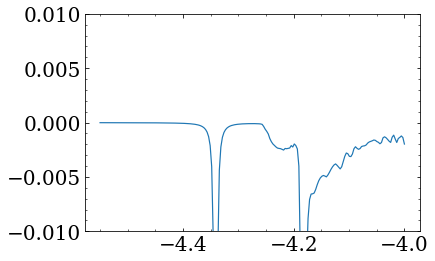

In [48]:
plt.plot(w,Im)
plt.ylim(-0.01,0.01)